In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [5]:
df.shape

(4685611, 90)

In [6]:
attack_set = df[df["label"] != "BENIGN"]
attack_sample = (attack_set.sample(n=50000, random_state=42, replace=True).reset_index(drop=True))

In [7]:
attack_sample.shape

(50000, 90)

In [8]:
print(attack_sample["label"].value_counts())

label
TFTP             10193
DrDoS_NTP         9861
DrDoS_DNS         9577
DrDoS_SNMP        4646
DrDoS_LDAP        3123
LDAP              3102
MSSQL             2062
UDP               1650
DrDoS_MSSQL       1584
DrDoS_SSDP        1180
DrDoS_UDP         1107
DrDoS_NetBIOS      722
NetBIOS            613
Syn                441
Portmap             67
UDP-lag             57
UDPLag              15
Name: count, dtype: int64


In [9]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=attack_sample.shape[0], replace=True, random_state=42)

In [10]:
benign_sample.shape

(50000, 90)

In [11]:
print(benign_sample["label"].value_counts())

label
BENIGN    50000
Name: count, dtype: int64


In [12]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [13]:
df_sample.shape

(100000, 90)

In [14]:
print(df_sample["label"].value_counts())

label
BENIGN           50000
TFTP             10193
DrDoS_NTP         9861
DrDoS_DNS         9577
DrDoS_SNMP        4646
DrDoS_LDAP        3123
LDAP              3102
MSSQL             2062
UDP               1650
DrDoS_MSSQL       1584
DrDoS_SSDP        1180
DrDoS_UDP         1107
DrDoS_NetBIOS      722
NetBIOS            613
Syn                441
Portmap             67
UDP-lag             57
UDPLag              15
Name: count, dtype: int64


In [15]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DrDoS_DNS': 1, 'DrDoS_LDAP': 2, 'DrDoS_MSSQL': 3, 'DrDoS_NTP': 4, 'DrDoS_NetBIOS': 5, 'DrDoS_SNMP': 6, 'DrDoS_SSDP': 7, 'DrDoS_UDP': 8, 'LDAP': 9, 'MSSQL': 10, 'NetBIOS': 11, 'Portmap': 12, 'Syn': 13, 'TFTP': 14, 'UDP': 15, 'UDP-lag': 16, 'UDPLag': 17}


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=128)

In [19]:
input_size = 88
hidden_size = 64
num_layers = 4
dropout = 0.5
num_classes = len(torch.unique(y_train_tensor))

class MultiClassDNN(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, dropout, num_classes):
        super(MultiClassDNN, self).__init__()
        layers = []
        in_features = input_dim
        for _ in range(num_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(dropout))
            in_features = hidden_size
        layers.append(nn.Linear(hidden_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

def build_model(input_dim, hidden_size, num_layers, dropout):
    return MultiClassDNN(
        input_dim=input_dim,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        num_classes=len(torch.unique(y_train_tensor))
    )

In [20]:
model = MultiClassDNN(input_size, hidden_size, num_layers, dropout, num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [21]:
def train_model(model, optimizer, train_loader, val_loader, epochs=20):
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        model.eval()
        val_loss = 0.0
        total = 0
        with torch.no_grad():
            for X_batch_val, y_batch_val in val_loader:
                outputs = model(X_batch_val)
                loss = criterion(outputs, y_batch_val)
                val_loss += loss.item() * X_batch_val.size(0)
                total += X_batch_val.size(0)
        val_loss = val_loss / total
    return val_loss

In [22]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    hidden_size = trial.suggest_categorical("hidden_size", [64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout = trial.suggest_float("dropout", 0.2, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=batch_size)
    model = build_model(
        input_dim=X_train.shape[1],
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    val_loss = train_model(model, optimizer, train_loader, val_loader)
    return val_loss

In [23]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)
print("Best params:", study.best_params)

[I 2026-04-22 14:05:56,687] A new study created in memory with name: no-name-505bd18e-df8e-4d24-9384-6851a6383856
[I 2026-04-22 14:06:46,484] Trial 0 finished with value: 0.9921486223220826 and parameters: {'lr': 1.6597675159433976e-05, 'hidden_size': 64, 'num_layers': 2, 'dropout': 0.22674568129178072, 'batch_size': 128}. Best is trial 0 with value: 0.9921486223220826.
[I 2026-04-22 14:08:54,431] Trial 1 finished with value: 0.8956005219459534 and parameters: {'lr': 0.0005653352801463744, 'hidden_size': 256, 'num_layers': 3, 'dropout': 0.22402901769600028, 'batch_size': 64}. Best is trial 1 with value: 0.8956005219459534.
[I 2026-04-22 14:09:49,339] Trial 2 finished with value: 0.909566985321045 and parameters: {'lr': 0.00034181647555080115, 'hidden_size': 128, 'num_layers': 2, 'dropout': 0.4750083755943311, 'batch_size': 128}. Best is trial 1 with value: 0.8956005219459534.
[I 2026-04-22 14:10:54,714] Trial 3 finished with value: 0.9453191643714904 and parameters: {'lr': 2.9694509504

Best params: {'lr': 0.0003558224262922999, 'hidden_size': 128, 'num_layers': 4, 'dropout': 0.22400374476014787, 'batch_size': 64}


In [24]:
best = study.best_params

model = build_model(
    input_dim=X_train.shape[1],
    hidden_size=best["hidden_size"],
    num_layers=best["num_layers"],
    dropout=best["dropout"]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"])

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=best["batch_size"], shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=best["batch_size"])

train_model(model, optimizer, train_loader, val_loader, epochs=50)

0.8958078676223755

In [25]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

PermutationExplainer explainer: 1001it [01:18, 12.75it/s]                                                              


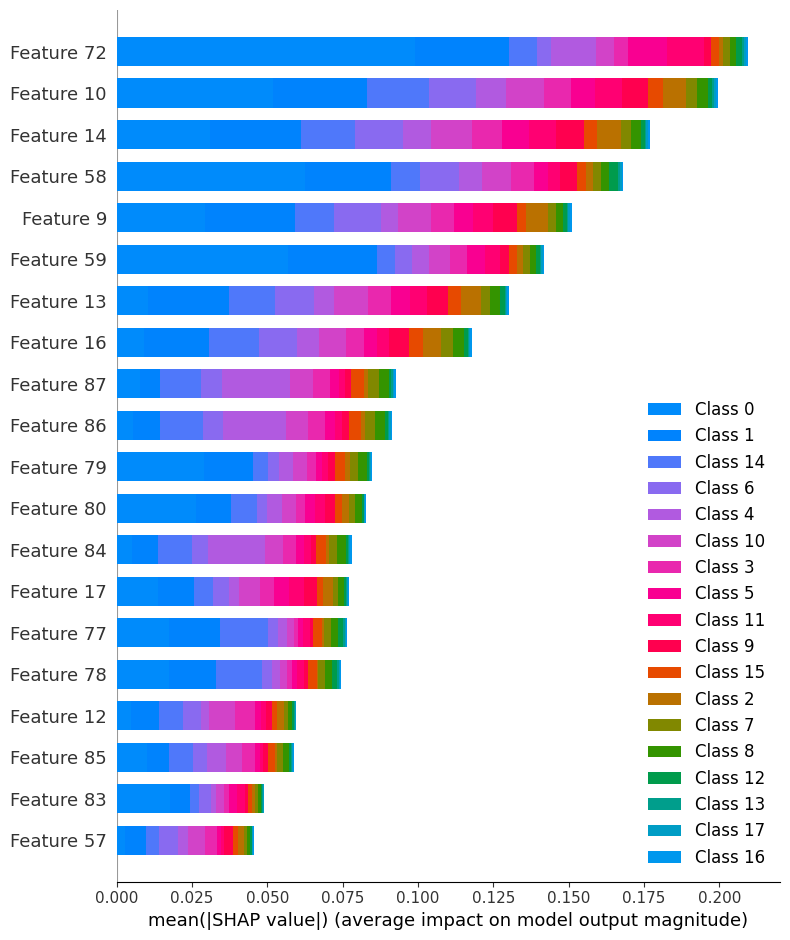

In [26]:
def predict_fn(X):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if not isinstance(X, np.ndarray):
        X = X.values
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = torch.softmax(model(X_tensor), dim=1)
    return outputs.cpu().numpy()
    
rng = np.random.default_rng(42)
X_sample = scaler.transform(X.sample(1000, random_state=42))
explainer = shap.Explainer(predict_fn, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=rng)

In [27]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.84415
Weighted F1: 0.8044221015243257
Macro F1: 0.4424513448566136
ROC-AUC: 0.9866688343549324


In [28]:
print(classification_report(y, y_pred, target_names=le.classes_))

               precision    recall  f1-score   support

       BENIGN       1.00      1.00      1.00     10000
    DrDoS_DNS       0.47      0.94      0.63      1916
   DrDoS_LDAP       0.00      0.00      0.00       625
  DrDoS_MSSQL       0.00      0.00      0.00       317
    DrDoS_NTP       1.00      0.99      1.00      1972
DrDoS_NetBIOS       0.47      0.90      0.62       144
   DrDoS_SNMP       0.63      0.14      0.23       929
   DrDoS_SSDP       0.00      0.00      0.00       236
    DrDoS_UDP       1.00      0.00      0.01       221
         LDAP       0.00      0.00      0.00       621
        MSSQL       0.51      0.94      0.66       412
      NetBIOS       1.00      0.11      0.20       123
      Portmap       0.50      0.31      0.38        13
          Syn       1.00      0.95      0.98        88
         TFTP       1.00      1.00      1.00      2039
          UDP       0.42      1.00      0.59       330
      UDP-lag       0.00      0.00      0.00        11
       UD

C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod